In [29]:


import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris (1).csv


In [30]:


df = pd.read_csv('/content/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [32]:

df.head(3)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa


In [33]:
# Step 2: Dataset Info

print(df.shape)
print(df.info())
print(df.describe())

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.5

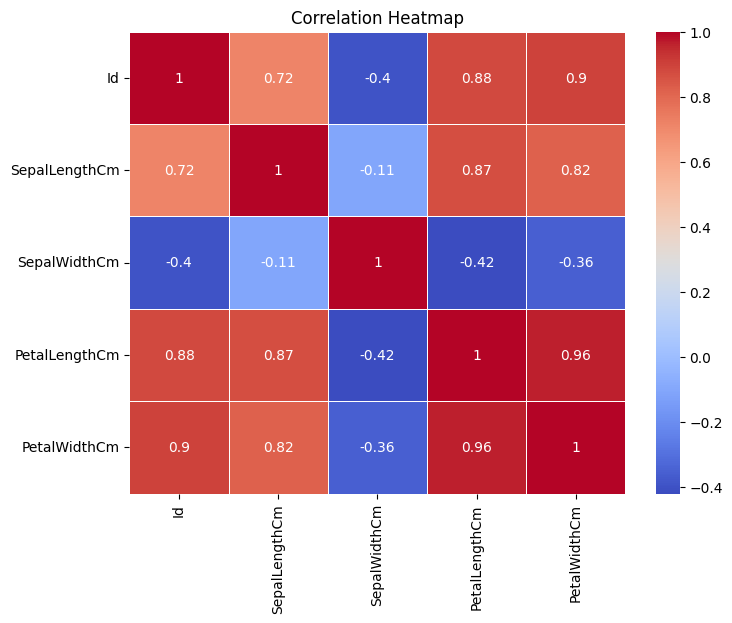

In [34]:
# ==========================================
# HEATMAP + HIGHLY CORRELATED COLUMNS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [35]:

# SHOW HIGHLY CORRELATED COLUMN PAIRS
threshold = 0.80
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:
            print(f"{col1}  <-->  {col2}  =  {corr_value:.2f}")

PetalLengthCm  <-->  Id  =  0.88
PetalLengthCm  <-->  SepalLengthCm  =  0.87
PetalWidthCm  <-->  Id  =  0.90
PetalWidthCm  <-->  SepalLengthCm  =  0.82
PetalWidthCm  <-->  PetalLengthCm  =  0.96


In [36]:
# Step 4: Check Missing Values

print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [37]:
# ==========================================
# STEP 5: REMOVE ID COLUMN
# ==========================================

if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


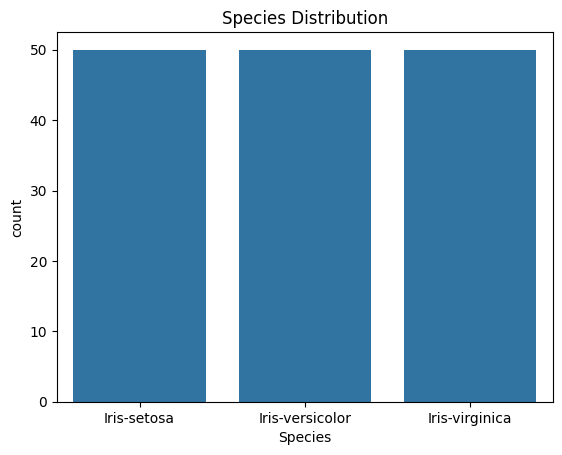

In [38]:
# ==========================================
# STEP 6: CLASS DISTRIBUTION
# ==========================================

sns.countplot(x='Species', data=df)

plt.title("Species Distribution")
plt.show()

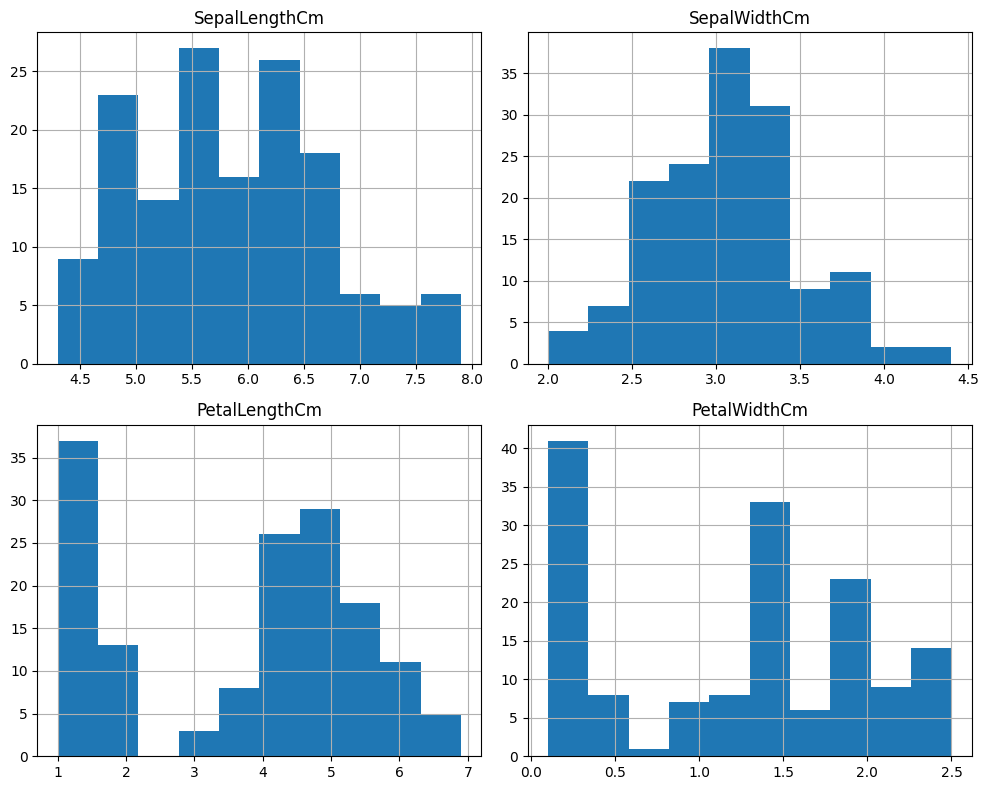

In [39]:
# ==========================================
# STEP 7: HISTOGRAMS
# ==========================================

df.hist(figsize=(10,8))

plt.tight_layout()
plt.show()

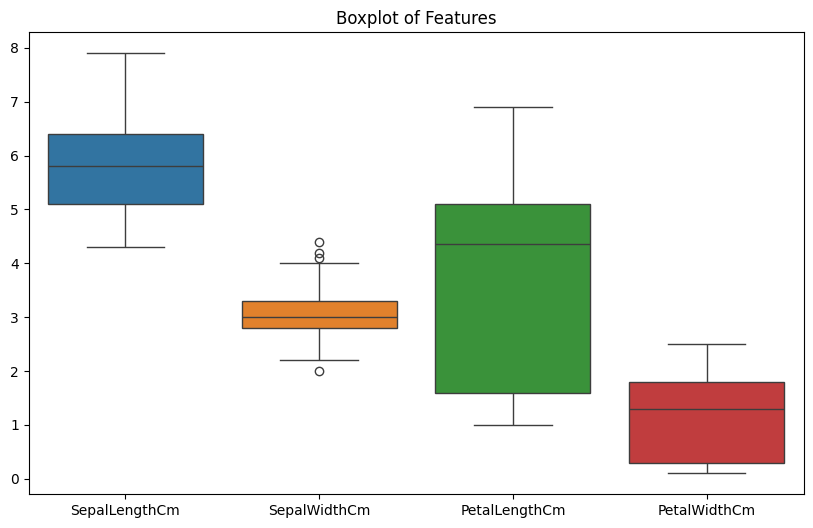

In [40]:
# ==========================================
# STEP 8: BOXPLOT
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(data=df.drop('Species', axis=1))

plt.title("Boxplot of Features")
plt.show()

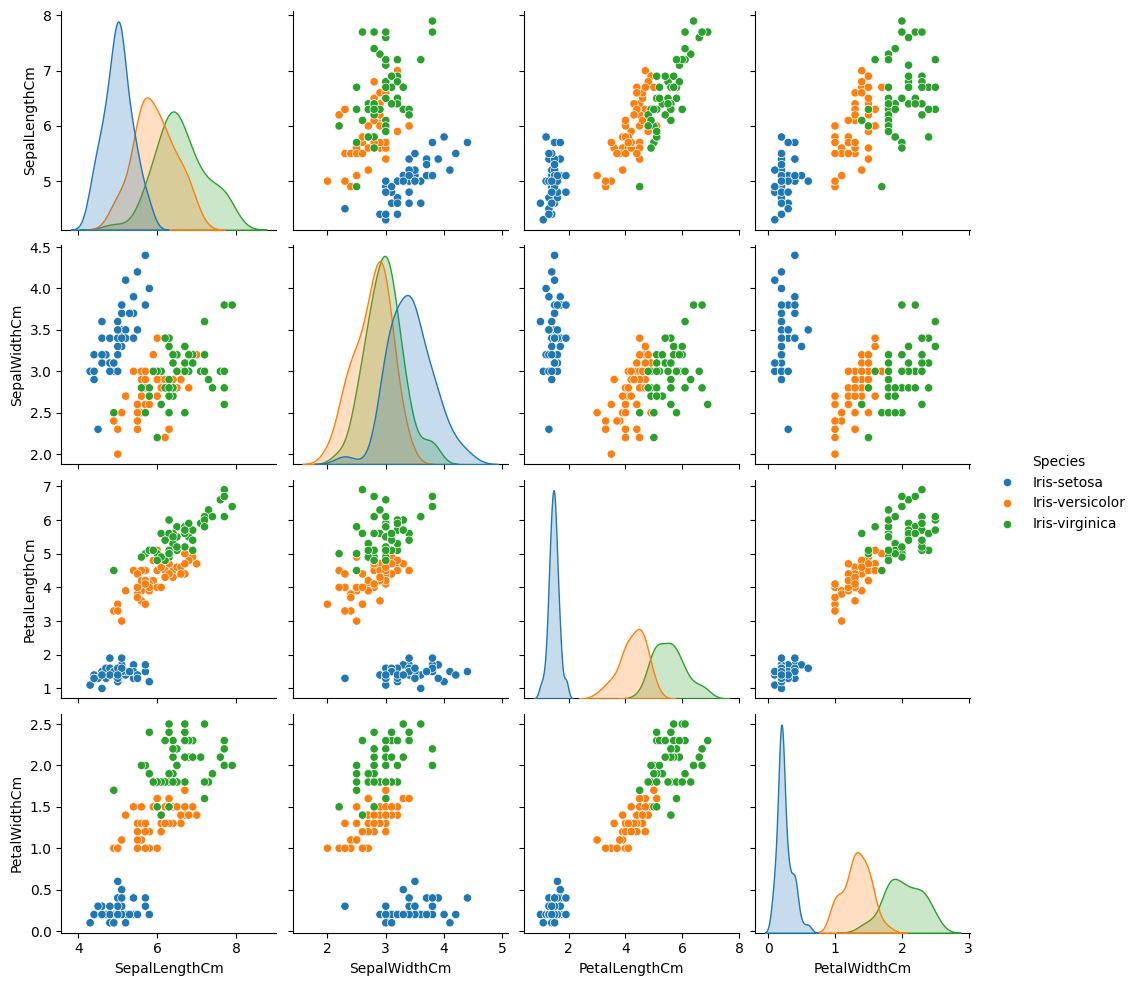

In [41]:
# ==========================================
# STEP 9: PAIRPLOT
# ==========================================

sns.pairplot(df, hue='Species')

plt.show()

In [42]:
# ==========================================
# STEP 12: LABEL ENCODING
# ==========================================

encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [43]:
# ==========================================
# STEP 13: FEATURES AND TARGET
# ==========================================

X = df.drop('Species', axis=1)

y = df['Species']

In [44]:
# ==========================================
# STEP 14: TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (120, 4)
Testing Shape: (30, 4)


In [45]:
# ==========================================
# STEP 15: FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [46]:
# ==========================================
# STEP 16: TRAIN MULTIPLE ML MODELS
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy*100:.2f}%")

Logistic Regression Accuracy: 100.00%
KNN Accuracy: 100.00%
Decision Tree Accuracy: 100.00%
SVM Accuracy: 100.00%


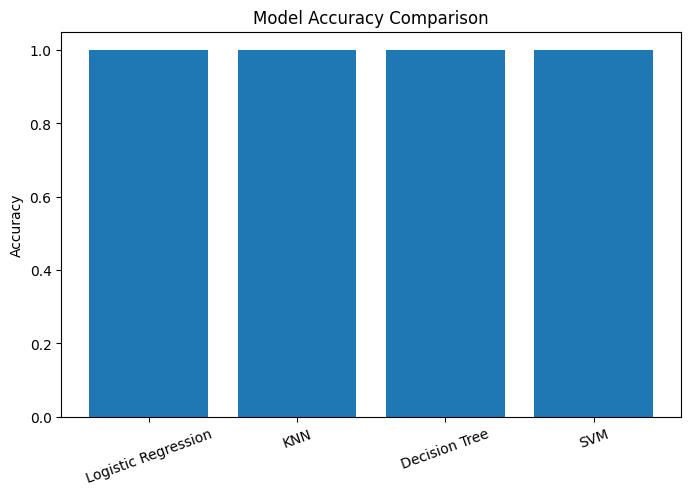

In [47]:
# ==========================================
# STEP 17: MODEL COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [48]:
# ==========================================
# STEP 18: BEST MODEL (SVM)
# ==========================================

model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:")

print(accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy Score:
1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



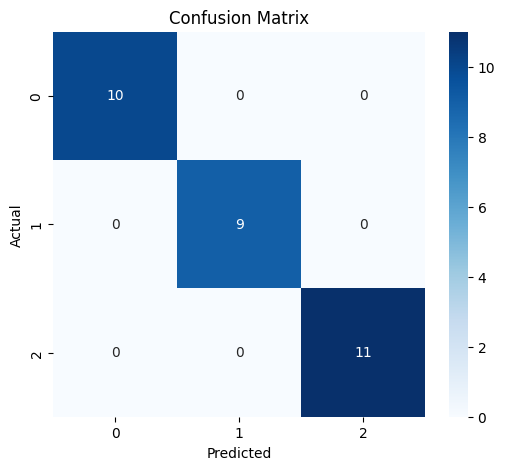

In [49]:
# ==========================================
# STEP 19: CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [50]:
# ==========================================
# ROC CURVE + AUC SCORE FOR ALL MODELS
# ==========================================

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

# Binarize target classes
y_bin = label_binarize(y, classes=[0,1,2])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_bin,
    test_size=0.2,
    random_state=42
)

# Scale data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
# ==========================================
# MODELS
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True)
}

Logistic Regression AUC Score: 0.9772
KNN AUC Score: 1.0000
Decision Tree AUC Score: 1.0000
SVM AUC Score: 1.0000


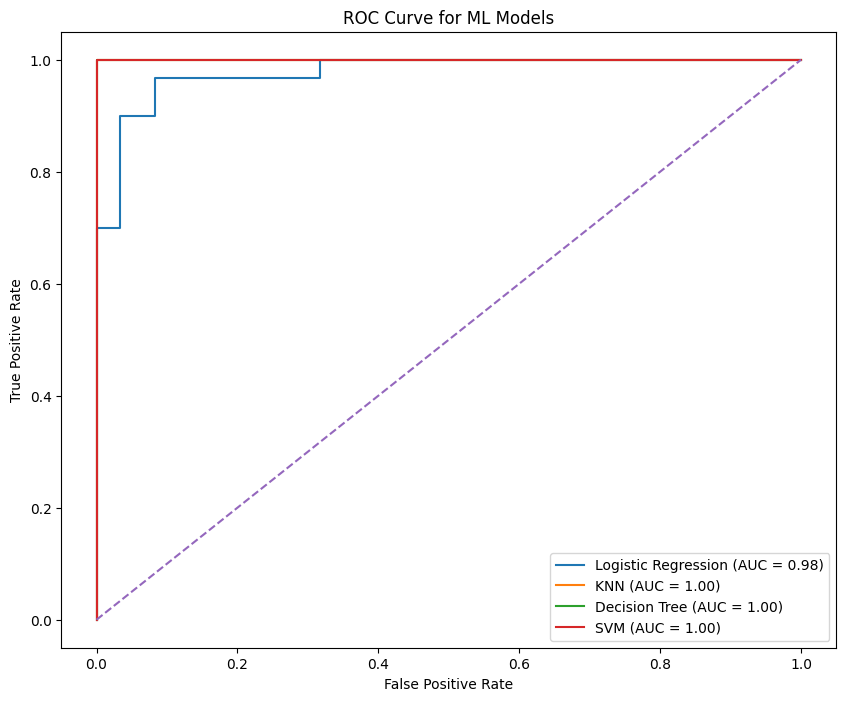

In [52]:
# ==========================================
# PLOT ROC CURVES
# ==========================================

plt.figure(figsize=(10,8))

for name, model in models.items():

    clf = OneVsRestClassifier(model)

    clf.fit(X_train, y_train)

    y_score = clf.predict_proba(X_test)

    # Micro-average ROC curve
    fpr, tpr, _ = roc_curve(
        y_test.ravel(),
        y_score.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.2f})"
    )

    print(f"{name} AUC Score: {roc_auc:.4f}")

# Random guess line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve for ML Models")

plt.legend()

plt.show()

In [53]:
# ==========================================
# COMPLETE ML RESULTS TO JSON
# Includes:
# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - AUC Score
# - Confusion Matrix
# - Hyperparameters
# - Predictions
# ==========================================

import json
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.multiclass import OneVsRestClassifier

# ==========================================
# RESULTS DICTIONARY
# ==========================================

results_json = {}

In [54]:
# ==========================================
# TRAIN AND STORE RESULTS
# ==========================================

for name, model in models.items():

    # One vs Rest for multiclass ROC/AUC
    clf = OneVsRestClassifier(model)

    # Train
    clf.fit(X_train, y_train)

    # Predictions
    y_pred = clf.predict(X_test)

    # Probabilities
    y_score = clf.predict_proba(X_test)

    # Convert one-hot encoded labels
    y_true_labels = np.argmax(y_test, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)

    # Metrics
    accuracy = accuracy_score(y_true_labels, y_pred_labels)

    precision = precision_score(
        y_true_labels,
        y_pred_labels,
        average='weighted'
    )

    recall = recall_score(
        y_true_labels,
        y_pred_labels,
        average='weighted'
    )

    f1 = f1_score(
        y_true_labels,
        y_pred_labels,
        average='weighted'
    )

    auc_score = roc_auc_score(
        y_test,
        y_score,
        multi_class='ovr'
    )

    cm = confusion_matrix(
        y_true_labels,
        y_pred_labels
    )

    # Classification Report
    class_report = classification_report(
        y_true_labels,
        y_pred_labels,
        output_dict=True
    )

    # Store everything
    results_json[name] = {

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1 Score": round(f1, 4),

        "AUC Score": round(auc_score, 4),

        "Confusion Matrix": cm.tolist(),

        "Hyperparameters": model.get_params(),

        "Predictions": y_pred_labels.tolist(),

        "Actual Values": y_true_labels.tolist(),

        "Classification Report": class_report
    }

In [55]:
# ==========================================
# CONVERT TO JSON FORMAT
# ==========================================

json_output = json.dumps(
    results_json,
    indent=4
)

print(json_output)

{
    "Logistic Regression": {
        "Accuracy": 0.8,
        "Precision": 0.819,
        "Recall": 0.8,
        "F1 Score": 0.7953,
        "AUC Score": 0.9418,
        "Confusion Matrix": [
            [
                10,
                0,
                0
            ],
            [
                4,
                5,
                0
            ],
            [
                0,
                2,
                9
            ]
        ],
        "Hyperparameters": {
            "C": 1.0,
            "class_weight": null,
            "dual": false,
            "fit_intercept": true,
            "intercept_scaling": 1,
            "l1_ratio": null,
            "max_iter": 100,
            "multi_class": "deprecated",
            "n_jobs": null,
            "penalty": "l2",
            "random_state": null,
            "solver": "lbfgs",
            "tol": 0.0001,
            "verbose": 0,
            "warm_start": false
        },
        "Predictions": [
            1,

In [56]:
# ==========================================
# SAVE JSON FILE
# ==========================================

with open("iris_complete_results.json", "w") as file:

    json.dump(
        results_json,
        file,
        indent=4
    )

print("JSON file saved successfully.")

JSON file saved successfully.


In [57]:
# ==========================================
# DOWNLOAD JSON FILE (COLAB)
# ==========================================

from google.colab import files

files.download("iris_complete_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>